In [2]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [2]:
(70/100)*5

3.5

In [3]:
(30/100)*9

2.6999999999999997

In [4]:
3/9

0.3333333333333333

In [5]:
2/9

0.2222222222222222

In [6]:
45/100*9

4.05

In [7]:
89/100*9

8.01

In [8]:
8/9

0.8888888888888888

In [9]:
percentile(30, make_array(4, 11, 12, 13, 15, 17, 18, 23, 24))

12

In [10]:
percentile(89, make_array(4, 11, 12, 13, 15, 17, 18, 23, 24))

24

In [11]:
nums = make_array(8, 6, 7, 5, 3, 0, 9)
np.sort(nums)

array([0, 3, 5, 6, 7, 8, 9])

In [12]:
nums

array([8, 6, 7, 5, 3, 0, 9])

In [13]:
percentile(75, np.sort(nums))

8

In [14]:
percentile(75, nums)

8

In [15]:
percentile(25, nums)

3

In [16]:
percentile(50, make_array(1, 1, 3, 5, 7, 8, 10, 11, 11, 15))

7

In [17]:
np.median(make_array(1, 1, 3, 5, 7, 8, 10, 11, 11, 15))

7.5

In [18]:
percentile(50, make_array(4, 5, 6, 7, 8, 11))

6

# Bootstrapping

In [19]:
# it's almost never possible to have the entire population, but we're going to practice with one
# all we usually get are samples
population = Table.read_table('data/san_francisco_2019.csv')
population.sample(10)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Journeyman Trade,Electrical Transit System Mech,107595,6884,48306,162785
"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Journeyman Trade,Electrical Transit System Mech,89838,17875,42853,150567
"Public Works, Transportation & Commerce",Public Utilities Commission,Journeyman Trade,"Sr. Stationary Eng, Sew Plant",116682,1849,47930,166462
General Administration & Finance,Administrative Services,Housekeeping & Laundry,Custodian,53130,10140,32282,95552
"Public Works, Transportation & Commerce",Municipal Transportation Agcy,Skilled Labor,Automotive Service Worker,86071,24626,41050,151747
General Administration & Finance,Registrar,"Budget, Admn & Stats Analysis",Junior Management Assistant,22786,5230,11457,39473
Human Welfare & Neighborhood Development,Human Services,Human Services,HSA Social Worker,86189,0,39121,125310
Culture & Recreation,Recreation And Park Commission,Housekeeping & Laundry,Custodian,27350,575,13920,41845
Public Protection,Police,Police Services,Police Officer,94887,9868,36596,141352
General Administration & Finance,Registrar,"Clerical, Secretarial & Steno",Junior Clerk,4277,833,397,5506


In [20]:
population.sort('Total Compensation', descending=True)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
General Administration & Finance,Retirement Services,Administrative & Mgmt (Unrep),Chief Investment Officer,577633,0,146398,724031
General Administration & Finance,Retirement Services,Unassigned,Managing Director,483072,0,134879,617951
General Administration & Finance,Retirement Services,Unassigned,Managing Director,482649,0,134905,617554
General Administration & Finance,Retirement Services,Unassigned,Managing Director,451507,0,120276,571784
General Administration & Finance,Retirement Services,Unassigned,Managing Director,449378,0,120857,570235
Community Health,Public Health,Administrative & Mgmt (Unrep),"Physician Administrator, DPH",434966,0,119213,554179
Public Protection,Sheriff,Correction & Detention,Senior Deputy Sheriff,152153,315896,77275,545324
General Administration & Finance,Retirement Services,Management,Director,397392,0,108913,506305
Community Health,Public Health,Medical & Dental,Supervising Physician Spec,404701,0,99480,504181
Community Health,Public Health,Medical & Dental,Senior Physician Specialist,400992,0,97428,498421


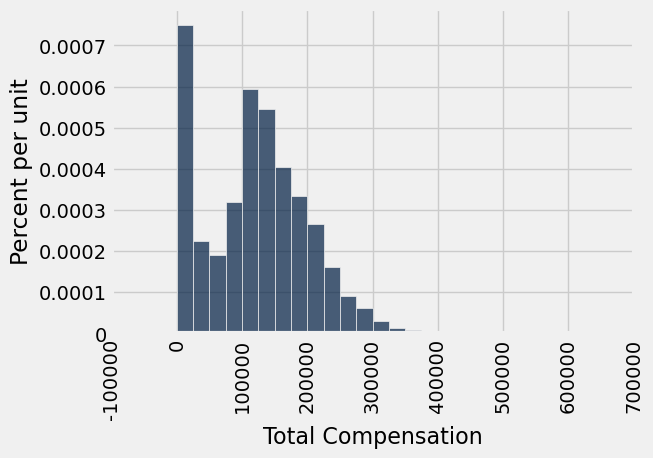

In [21]:
population.hist('Total Compensation', bins=np.arange(0, 600000, 25000))

In [22]:
population.sort('Total Compensation')

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Probation & Parole,Deputy Probation Officer,0,0,0,0
Public Protection,Fire Department,"Clerical, Secretarial & Steno",Senior Clerk Typist,0,0,0,0
Public Protection,Juvenile Court,Correction & Detention,"Counselor, Juvenile Hall PERS",0,0,0,0
Public Protection,Police,"Clerical, Secretarial & Steno",Clerk Typist,0,0,0,0
Public Protection,Sheriff,Correction & Detention,Deputy Sheriff,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,Sub-Professional Engineering,StdntDsgn Train2/Arch/Eng/Plng,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,"Clerical, Secretarial & Steno",Executive Secretary 1,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,"Payroll, Billing & Accounting",Senior Account Clerk,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,Housekeeping & Laundry,Custodian,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,Housekeeping & Laundry,Custodian,0,0,0,0


In [23]:
min_salary = 15 * 20 * 50 # min. wage was $15, part time, 2 weeks of vacation
min_salary

15000

In [25]:
population = population.where('Salary', are.above_or_equal_to(min_salary))
population

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Information Systems,IS Trainer-Journey,91332,0,40059,131391
Public Protection,Adult Probation,Information Systems,IS Engineer-Assistant,123241,0,49279,172520
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Senior,115715,0,46752,162468
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Principal,159394,0,57312,216706
Public Protection,Adult Probation,Information Systems,IS Programmer Analyst,70035,0,28671,98706
Public Protection,Adult Probation,Information Systems,IS Project Director,175742,0,60830,236572
Public Protection,Adult Probation,Information Systems,IT Operations Support Admin IV,123840,0,49429,173269
Public Protection,Adult Probation,"Payroll, Billing & Accounting",Accountant III,111816,0,46319,158135
Public Protection,Adult Probation,"Budget, Admn & Stats Analysis",Statistician,87725,0,38899,126624
Public Protection,Adult Probation,"Budget, Admn & Stats Analysis",Senior Administrative Analyst,116192,0,47651,163843


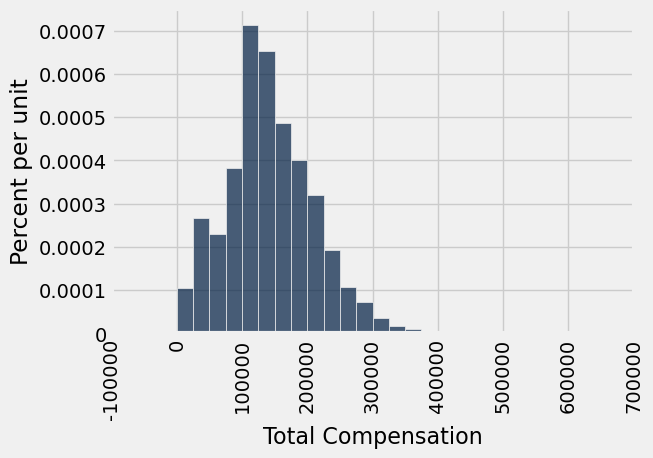

In [26]:
population.hist('Total Compensation', bins=np.arange(0, 600000, 25000))

In [27]:
pop_median = percentile(50, population.column('Total Compensation'))
pop_median

135747.0

In [28]:
# np.median works too!
np.median(population.column('Total Compensation'))

135747.0

## Let's pretend we took a sample of 400 people, and that's all we have

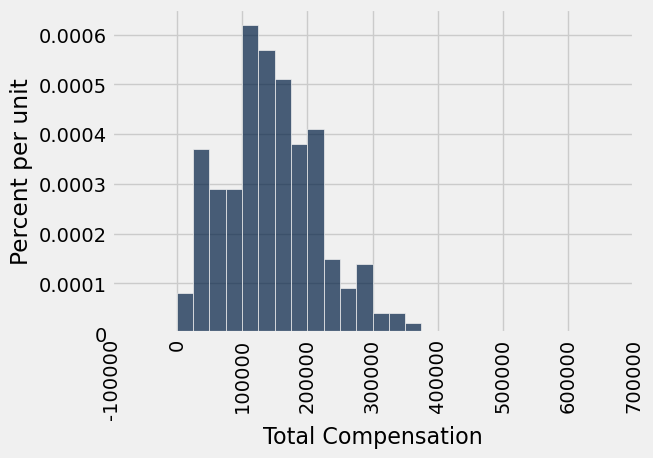

In [29]:
sample_size = 400
sample = population.sample(sample_size, with_replacement=False) # 400 separate people
sample.hist('Total Compensation', bins=np.arange(0, 600000, 25000))

In [30]:
percentile(50, sample.column('Total Compensation'))

138166.0

130826.0

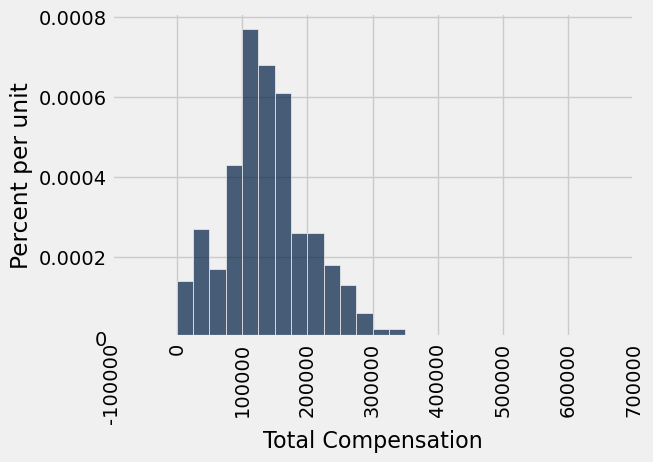

In [31]:
sample_size = 400
sample2 = population.sample(sample_size, with_replacement=False) # 400 separate people
sample2.hist('Total Compensation', bins=np.arange(0, 600000, 25000))
percentile(50, sample2.column('Total Compensation'))

In [37]:
resample = sample.sample(sample.num_rows, with_replacement=True) # sample.sample() would work here
percentile(50, resample.column('Total Compensation'))

138373.0

In [46]:
def one_bootstrap_median():
    # draw the bootstrap sample
    resample = sample.sample()
    # retrn the median total comp. in the bootstrap sample
    return percentile(50, resample.column('Total Compensation'))

In [39]:
bootstrapped_sample_medians = make_array()
num_resamples = 1000

for i in np.arange(num_resamples):
    new_median = one_bootstrap_median()
    bootstrapped_sample_medians = np.append(bootstrapped_sample_medians, new_median)

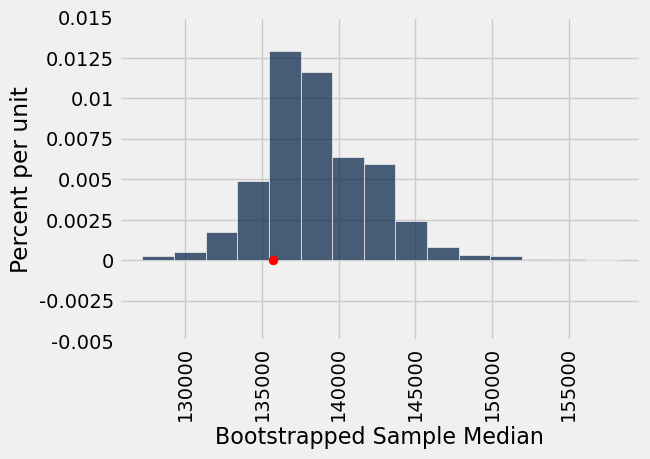

In [42]:
bootstrapped_median_table = Table().with_column('Bootstrapped Sample Median', bootstrapped_sample_medians)
bootstrapped_median_table.hist(bins=15)

plt.ylim(-0.00005, 0.00015)
plt.scatter(pop_median, 0, color='red', s=40);

In [44]:
# middle 95% of our estimates gives us an estimate that's correct 95% of the time
# 2.5% -- 97.5% is the range we want here -- that's the middle 95%
# called a *confidence interval*
percentile(2.5, bootstrapped_sample_medians), percentile(97.5, bootstrapped_sample_medians)

(131933.0, 145938.0)

In [45]:
# 90% confidence interval
percentile(5, bootstrapped_sample_medians), percentile(95, bootstrapped_sample_medians)

(133249.0, 144656.0)

In [48]:
population_mean = population.column('Total Compensation').mean()
population_mean

142675.017788319

In [49]:
# Crushed ICE: using bootstrap sampling and our size 400 sample,
# calculate a 95% confidence interval for the average total comp.

In [51]:
sample.column('Total Compensation').mean()

145288.08749999999

In [52]:
def one_bootstrap_average():
    # draw the bootstrap sample
    resample = sample.sample()
    # retrn the median total comp. in the bootstrap sample
    return np.average(resample.column('Total Compensation'))

In [56]:
one_bootstrap_average()

140755.7225

In [59]:
bootstrapped_sample_averages = make_array()
num_resamples = 1000

for i in np.arange(num_resamples):
    new_average = one_bootstrap_average()
    bootstrapped_sample_averages = np.append(bootstrapped_sample_averages, new_average)

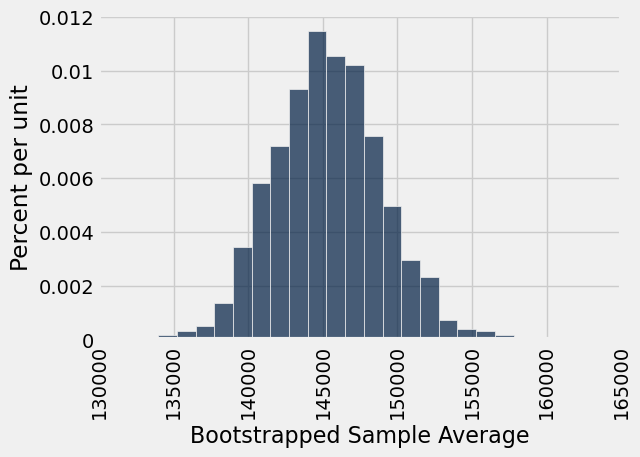

In [60]:
Table().with_column('Bootstrapped Sample Average', bootstrapped_sample_averages).hist(bins=20)


In [61]:
percentile(2.5, bootstrapped_sample_averages), percentile(97.5, bootstrapped_sample_averages)

(138720.16, 152345.70250000001)

---

# Titanic

In [3]:
titanic = Table.read_table('data/titanic.csv')
titanic

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,nan,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,nan,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,nan,S
6,0,3,"Moran, Mr. James",male,nan,0,0,330877,8.4583,nan,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,nan,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,nan,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,nan,C


In [5]:
titanic2 = titanic.where('Age', are.above_or_equal_to(0))
titanic2

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,nan,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,nan,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,nan,S
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,nan,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,nan,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,nan,C
11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S


In [12]:
# take a size 100 sample without replacement
sample = titanic2.sample(100, with_replacement=False)
# make a function to generate a resample from your original sample and give back the avg. age
def one_bootstrap_average():
    resample = sample.sample()
    return resample.column('Age').mean()

In [20]:
one_bootstrap_average()

30.649999999999999

In [21]:
# Generate averages from 5000 bootstrap samples
num_repetitions = 5000
bstrap_means = make_array()
for i in np.arange(num_repetitions):
    bstrap_means = np.append(bstrap_means, one_bootstrap_average())

(26.420000000000002, 32.130000000000003)

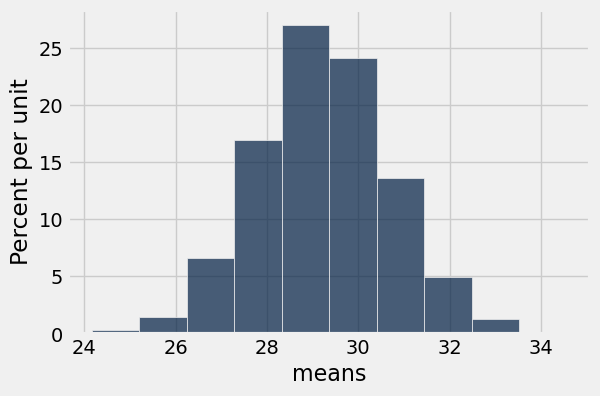

In [25]:
# Get a 95% confidence interval for the average age
Table().with_column('means', bstrap_means).hist()
percentile(2.5, bstrap_means), percentile(97.5, bstrap_means)

In [26]:
titanic2.column('Age').mean()

29.69911764705882